In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/processed/clean_supplement_sales.csv",
    parse_dates=["Order_Date"]
)

df.head()

,Order_ID,Order_Date,Customer_ID,Age,Gender,State,Product_Name,Category,Quantity,Unit_Price,Revenue,Payment_Method,Channel,Customer_Type,Year,Month,Month_Name,Quarter
0,ORD00001,2024-09-27,CUST6191,38,Male,Haryana,Immunity Booster,Immunity,4,649,2596,Debit Card,Flipkart,New,2024,9,September,3
1,ORD00002,2025-10-25,CUST9322,39,Male,Maharashtra,Weight Control Capsules,Weight Management,4,1199,4796,COD,Amazon,New,2025,10,October,4
2,ORD00003,2024-06-09,CUST5555,39,Male,Punjab,Detox Tea,Detox,5,599,2995,UPI,Flipkart,Repeat,2024,6,June,2
3,ORD00004,2025-11-30,CUST1189,20,Male,Karnataka,Hair Serum,Hair Care,4,699,2796,Debit Card,Website,Repeat,2025,11,November,4
4,ORD00005,2025-08-23,CUST9433,26,Female,Bihar,Hair Serum,Hair Care,4,699,2796,Credit Card,Flipkart,Repeat,2025,8,August,3


In [4]:
monthly_revenue = (
    df.groupby(
        pd.Grouper(
            key="Order_Date",
            freq="ME"
        )
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Order_Date,Revenue
0,2024-01-31,1026787
1,2024-02-29,852119
2,2024-03-31,1091531
3,2024-04-30,1008578
4,2024-05-31,968623


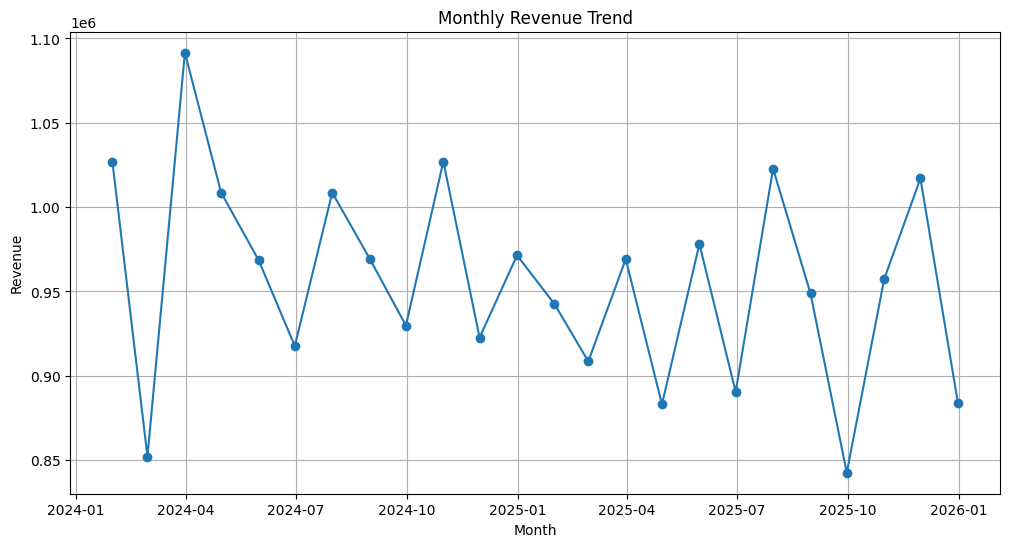

In [5]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Order_Date"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [8]:
monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]


Order_Date    2024-03-31 00:00:00
Revenue                   1091531
Name: 2, dtype: object

In [9]:
monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

Order_Date    2025-09-30 00:00:00
Revenue                    842503
Name: 20, dtype: object

In [10]:
monthly_revenue.to_csv(
    "../data/processed/monthly_revenue.csv",
    index=False
)

print("Monthly Revenue Dataset Saved")

Monthly Revenue Dataset Saved


In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
monthly_revenue["Month_Index"] = np.arange(
    len(monthly_revenue)
)

monthly_revenue.head()

,Order_Date,Revenue,Month_Index
0,2024-01-31,1026787,0
1,2024-02-29,852119,1
2,2024-03-31,1091531,2
3,2024-04-30,1008578,3
4,2024-05-31,968623,4


In [13]:
X = monthly_revenue[["Month_Index"]]
y = monthly_revenue["Revenue"]

model = LinearRegression()

model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [14]:
future_index = np.arange(
    len(monthly_revenue),
    len(monthly_revenue) + 3
).reshape(-1, 1)

future_predictions = model.predict(
    future_index
)

future_predictions

c:\Users\user\Desktop\Supplement-Sales-Intelligence-Dashboard\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([922966.65942029, 920342.70550725, 917718.7515942 ])

In [15]:
future_dates = pd.date_range(
    start=monthly_revenue["Order_Date"].max(),
    periods=4,
    freq="ME"
)[1:]

forecast_df = pd.DataFrame({
    "Forecast_Month": future_dates,
    "Predicted_Revenue": future_predictions
})

forecast_df

,Forecast_Month,Predicted_Revenue
0,2026-01-31,922966.659420
1,2026-02-28,920342.705507
2,2026-03-31,917718.751594


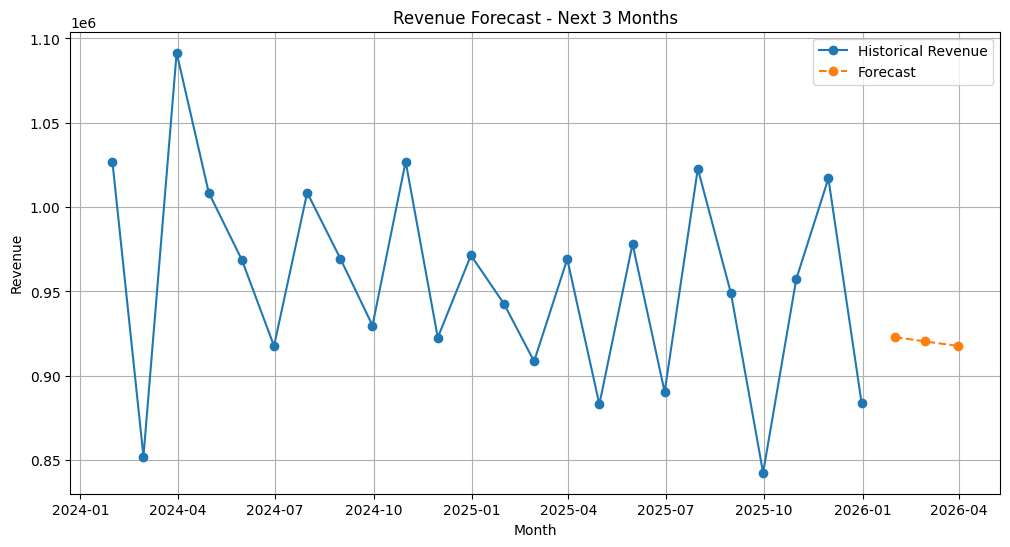

: 

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Order_Date"],
    monthly_revenue["Revenue"],
    marker="o",
    label="Historical Revenue"
)

plt.plot(
    forecast_df["Forecast_Month"],
    forecast_df["Predicted_Revenue"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Revenue Forecast - Next 3 Months")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()